# Importation des bibliothèques

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score
import seaborn as sns
import numpy as np


In [2]:

# Définir les chemins des données
train_csv_path = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/processed/train_split.csv'
val_csv_path = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/processed/val_split.csv'
test_csv_path = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/processed/test_split.csv'

train_img_dir = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/train_image'
val_img_dir = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/val_image'
test_img_dir = 'C:/Users/Dell/OneDrive/Desktop/Projet_final_BIHAR/Jean_Duckens_Final_Evaluation/data/test_image'

# Charger les données CSV
train_df = pd.read_csv(train_csv_path, on_bad_lines='warn')
val_df = pd.read_csv(val_csv_path, on_bad_lines='warn')
test_df = pd.read_csv(test_csv_path, on_bad_lines='warn')

## Transformation des labels pour la classification multi-label

In [3]:

# Fonction pour convertir les labels string en liste de labels
def parse_labels(label_str):
    # Supposons que vos labels sont stockés sous forme de "[3,4]" ou "[5,7]"
    # Nous devons les convertir en liste d'entiers
    if isinstance(label_str, str):
        # Supprimer les crochets et divisez par virgule
        labels = label_str.strip('[]').split(',')
        # Convertir en entiers et retourner sous forme de liste
        return [int(label) for label in labels if label.strip()]
    return []

# Appliquer la fonction de parsing aux colonnes de labels
train_df['Labels_list'] = train_df['Labels_list'].apply(parse_labels)
val_df['Labels_list'] = val_df['Labels_list'].apply(parse_labels)
test_df['Labels_list'] = test_df['Labels_list'].apply(parse_labels)

In [4]:
train_df.head()

,ImageID,Labels,Caption,Labels_list
0,9306.jpg,17,A stuffed animal cat stands in a pair of shoes.,[17]
1,12244.jpg,11 10 3,A fire hydrant is sitting on a street corner.,"[11, 10, 3]"
2,28931.jpg,11,A red fire hydrant is on the curb in front of ...,[11]
3,29430.jpg,8,there is a very old rusted truck that is parke...,[8]
4,11288.jpg,6,The front of a metro bus picking up passengers,[6]


## Prétraitement et normalisation des images

Classes: [ 2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Nombre de classes: 17
X_train shape: (11146, 224, 224, 3)
y_train shape: (11146, 17)
X_val shape: (2388, 224, 224, 3)
y_val shape: (2388, 17)


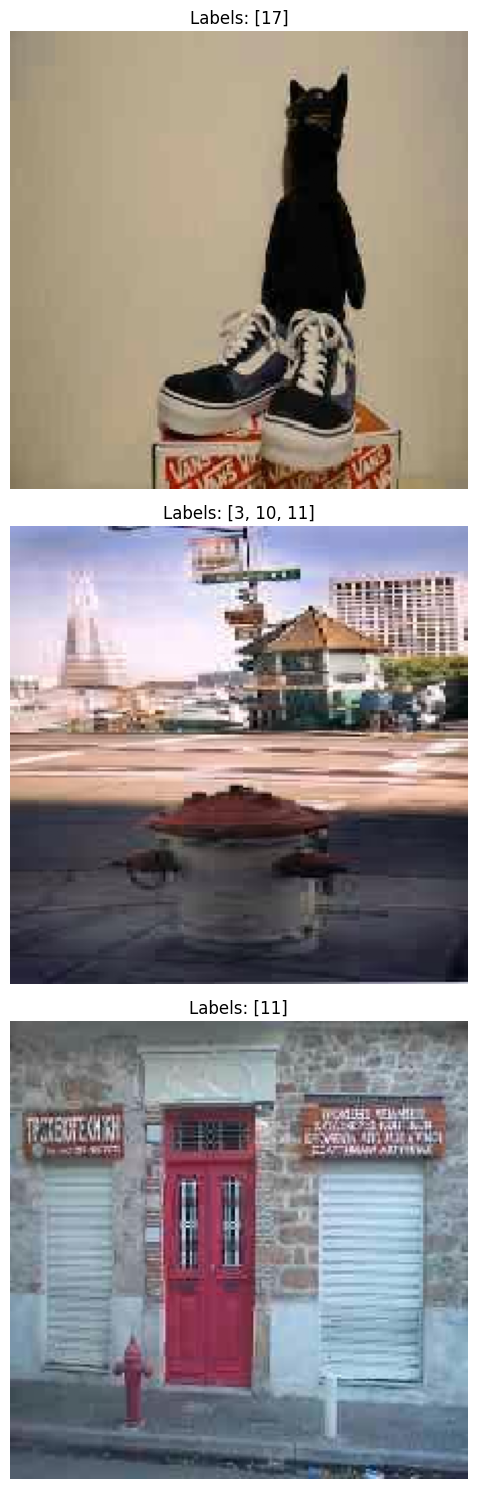

In [5]:


# Créer un MultiLabelBinarizer pour convertir en one-hot encoding
mlb = MultiLabelBinarizer()
train_labels_encoded = mlb.fit_transform(train_df['Labels_list'])
val_labels_encoded = mlb.transform(val_df['Labels_list'])
test_labels_encoded = mlb.transform(test_df['Labels_list'])

# Afficher les classes
print(f"Classes: {mlb.classes_}")
print(f"Nombre de classes: {len(mlb.classes_)}")

# Paramètres pour le prétraitement des images
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

# Fonction pour charger et prétraiter les images
def load_and_preprocess_images(image_ids, img_dir, target_size=(IMG_HEIGHT, IMG_WIDTH)):
    images = []
    for img_id in image_ids:
        # Trouver l'image (peut nécessiter une adaptation si les noms de fichiers diffèrent des IDs)
        img_path = os.path.join(img_dir, img_id)
        # Vérifier si le fichier existe
        if not os.path.exists(img_path):
            # Essayer avec des extensions communes
            for ext in ['.jpg', '.jpeg', '.png']:
                test_path = img_path + ext
                if os.path.exists(test_path):
                    img_path = test_path
                    break
        
        if os.path.exists(img_path):
            # Charger l'image
            img = load_img(img_path, target_size=target_size)
            # Convertir en tableau numpy
            img_array = img_to_array(img)
            # Normaliser les pixels à [0,1]
            img_array = img_array / 255.0
            images.append(img_array)
        else:
            print(f"Image non trouvée: {img_id}")
    
    return np.array(images)

# Charger et prétraiter les images d'entraînement, validation et test
X_train = load_and_preprocess_images(train_df['ImageID'], train_img_dir)
X_val = load_and_preprocess_images(val_df['ImageID'], val_img_dir)
X_test = load_and_preprocess_images(test_df['ImageID'], test_img_dir)

y_train = train_labels_encoded
y_val = val_labels_encoded
y_test = test_labels_encoded

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Visualiser quelques images avec leurs labels
def show_images_with_labels(images, labels, class_names, num_images=3):
    plt.figure(figsize=(15, 5*num_images))
    for i in range(min(num_images, len(images))):
        plt.subplot(num_images, 1, i+1)
        plt.imshow(images[i])
        
        # Trouver les indices où la valeur est 1 (les classes présentes)
        present_classes = np.where(labels[i] == 1)[0]
        class_names_present = [class_names[idx] for idx in present_classes]
        
        plt.title(f"Labels: {class_names_present}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Afficher quelques images d'entraînement avec leurs labels
show_images_with_labels(X_train, y_train, mlb.classes_)

# 2. Conception d'un CNN personnalisé pour la classification multi-label

In [9]:

# Définir les paramètres du modèle
num_classes = len(mlb.classes_)
input_shape = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Construire un modèle CNN simple
def build_custom_cnn():
    model = Sequential([
        # Premier bloc de convolution
        Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Deuxième bloc de convolution
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Troisième bloc de convolution
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Couche fully connected
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # Couche de sortie - sigmoid pour classification multi-label
        Dense(num_classes, activation='sigmoid')
    ])
    
    return model

# Compiler le modèle avec des métriques adaptées à la classification multi-label
def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',  # Approprié pour multi-label
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model

# Créer et compiler le modèle
custom_model = build_custom_cnn()
custom_model = compile_model(custom_model)

# Résumé du modèle
custom_model.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 batch_normalization_7 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 conv2d_7 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 batch_normalization_8 (Batc  (None, 224, 224, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                                             
                                                      

## Configuration des ressources de calcul

In [10]:
import tensorflow as tf
import os
import multiprocessing

num_threads = multiprocessing.cpu_count()
os.environ["OMP_NUM_THREADS"] = str(num_threads)
os.environ["TF_NUM_INTRAOP_THREADS"] = str(num_threads)
os.environ["TF_NUM_INTEROP_THREADS"] = str(num_threads)

tf.config.threading.set_intra_op_parallelism_threads(num_threads)
tf.config.threading.set_inter_op_parallelism_threads(num_threads)

print(f"Nombre de threads utilisés : {num_threads}")


Nombre de threads utilisés : 4


## Entraînement du modèle avec callbacks

In [11]:
# Définir des callbacks pour améliorer l'entraînement
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-6
    )
]

# Entraîner le modèle
history = custom_model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Epoch 1/5
349/349 [==============================] - 3951s 11s/step - loss: 0.4483 - accuracy: 0.8154 - precision: 0.1183 - recall: 0.1709 - val_loss: 0.3773 - val_accuracy: 0.9124 - val_precision: 0.6923 - val_recall: 0.0025 - lr: 0.0010
Epoch 2/5
349/349 [==============================] - 3769s 11s/step - loss: 0.2940 - accuracy: 0.9052 - precision: 0.3163 - recall: 0.0690 - val_loss: 0.2722 - val_accuracy: 0.9109 - val_precision: 0.4311 - val_recall: 0.0483 - lr: 0.0010
Epoch 3/5
349/349 [==============================] - 4009s 11s/step - loss: 0.2721 - accuracy: 0.9086 - precision: 0.4037 - recall: 0.0873 - val_loss: 0.2687 - val_accuracy: 0.9133 - val_precision: 0.6133 - val_recall: 0.0312 - lr: 0.0010
Epoch 4/5
349/349 [==============================] - 4565s 13s/step - loss: 0.2585 - accuracy: 0.9105 - precision: 0.4511 - recall: 0.0934 - val_loss: 0.2579 - val_accuracy: 0.9129 - val_precision: 0.5290 - val_recall: 0.0615 - lr: 0.0010
Epoch 5/5
349/349 [=========================

##  Évaluation des performances et diagnostics d'apprentissage

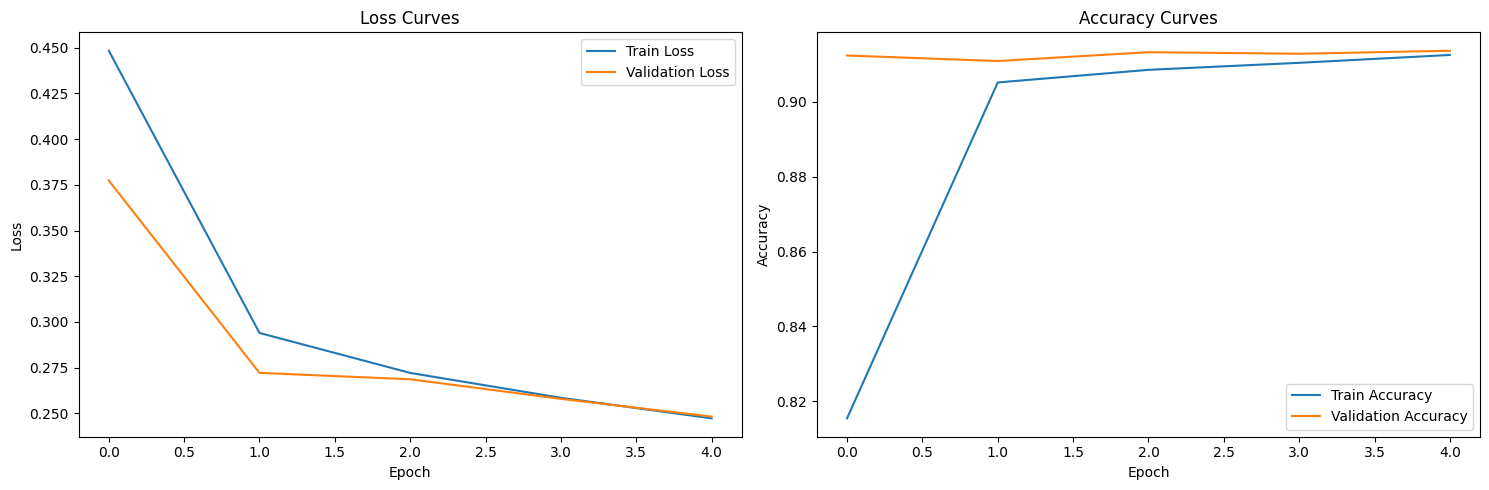

75/75 [==============================] - 191s 3s/step - loss: 0.2493 - accuracy: 0.9137 - precision: 0.5837 - recall: 0.0423
Test Loss: 0.2493
Test Accuracy: 0.9137
Test Precision: 0.5837
Test Recall: 0.0423
75/75 [==============================] - 193s 3s/step

Métriques par classe:
Classe 2:
  Average Precision: 0.1501
  AUC-ROC: 0.6932
Classe 3:
  Average Precision: 0.3987
  AUC-ROC: 0.6860
Classe 4:
  Average Precision: 0.3876
  AUC-ROC: 0.8022
Classe 5:
  Average Precision: 0.5251
  AUC-ROC: 0.8933
Classe 6:
  Average Precision: 0.4156
  AUC-ROC: 0.8235
Classe 7:
  Average Precision: 0.3817
  AUC-ROC: 0.8157
Classe 8:
  Average Precision: 0.2800
  AUC-ROC: 0.7160
Classe 9:
  Average Precision: 0.2979
  AUC-ROC: 0.7916
Classe 10:
  Average Precision: 0.2162
  AUC-ROC: 0.7659
Classe 11:
  Average Precision: 0.1357
  AUC-ROC: 0.7087
Classe 13:
  Average Precision: 0.1685
  AUC-ROC: 0.7032
Classe 14:
  Average Precision: 0.0272
  AUC-ROC: 0.7092
Classe 15:
  Average Precision: 0.2074


c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\OneDrive\Desktop\Projet_final_BIHAR\Jean_Duckens_Final_Evaluation\venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


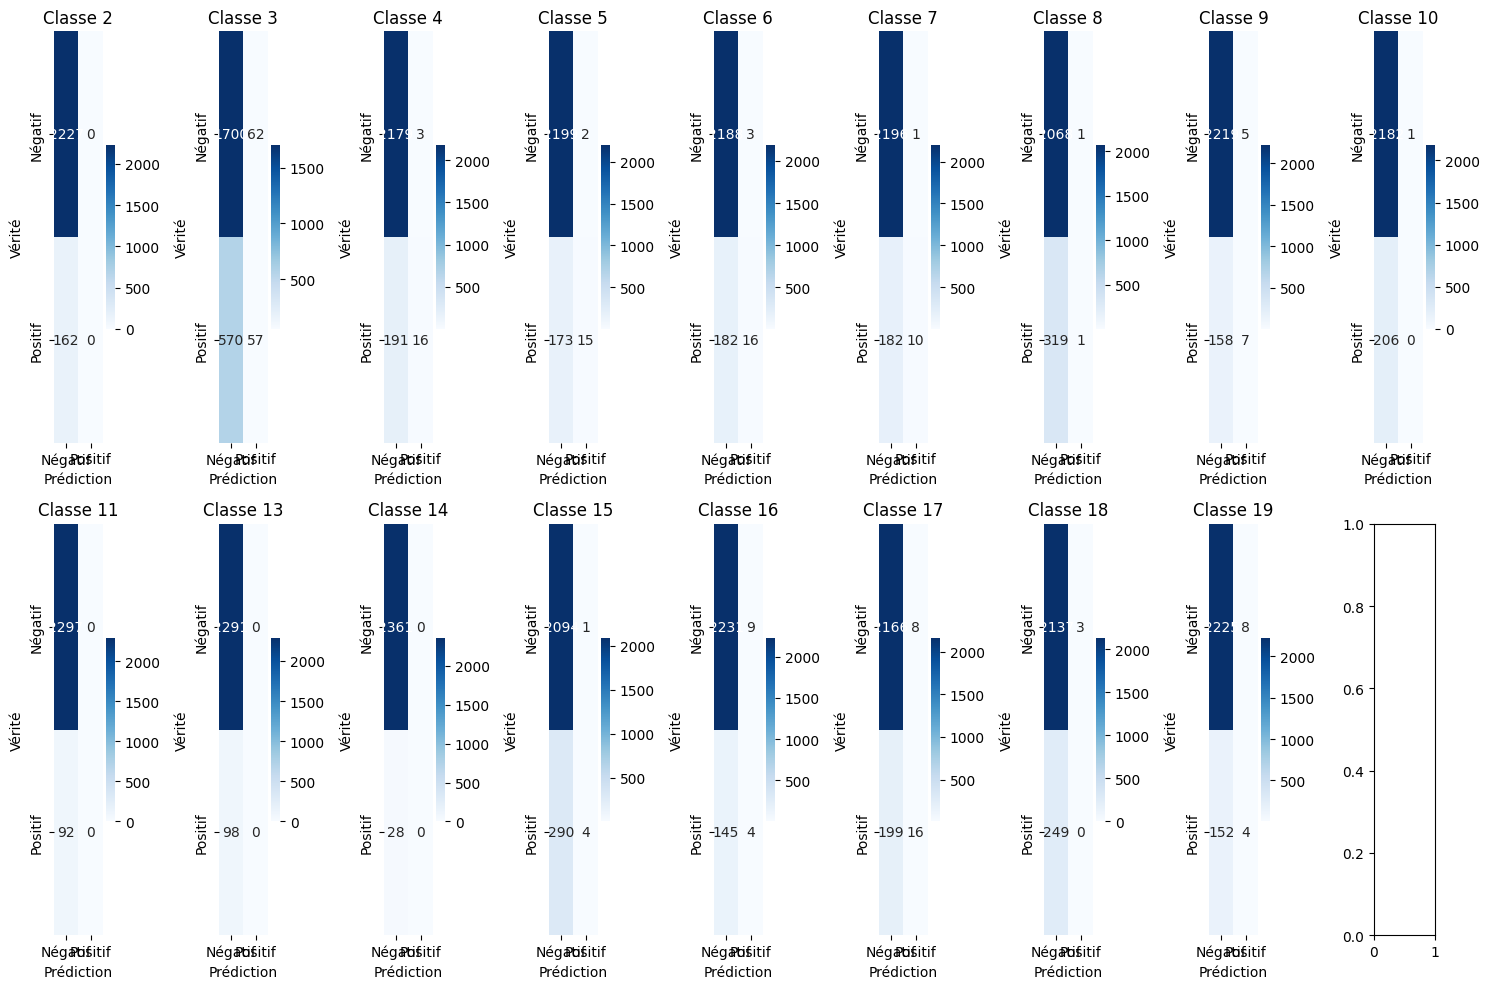

In [14]:

# Tracer les courbes d'apprentissage
def plot_learning_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Tracer la perte
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    # Tracer l'accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[1].set_title('Accuracy Curves')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

# Évaluer le modèle sur l'ensemble de test
test_loss, test_accuracy, test_precision, test_recall = custom_model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")

# Faire des prédictions sur l'ensemble de test
y_pred_prob = custom_model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)  # Seuil de 0.5 pour la classification binaire

# Calculer métriques supplémentaires pour chaque classe
average_precision = average_precision_score(y_test, y_pred_prob, average=None)
auc_roc = roc_auc_score(y_test, y_pred_prob, average=None)

print("\nMétriques par classe:")
for i, class_name in enumerate(mlb.classes_):
    print(f"Classe {class_name}:")
    print(f"  Average Precision: {average_precision[i]:.4f}")
    print(f"  AUC-ROC: {auc_roc[i]:.4f}")

# Rapport de classification
print("\nRapport de classification:")
report = classification_report(y_test, y_pred, target_names=[str(c) for c in mlb.classes_])
print(report)

# Afficher la matrice de confusion pour chaque classe
def plot_confusion_matrices(y_true, y_pred, class_names):
    num_classes = len(class_names)
    fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(num_classes):
        cm = confusion_matrix(y_true[:, i], y_pred[:, i])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'Classe {class_names[i]}')
        axes[i].set_xlabel('Prédiction')
        axes[i].set_ylabel('Vérité')
        axes[i].set_xticklabels(['Négatif', 'Positif'])
        axes[i].set_yticklabels(['Négatif', 'Positif'])
        
    plt.tight_layout()
    plt.show()

plot_confusion_matrices(y_test, y_pred, mlb.classes_)

# Expérimentations avec des architectures CNN avancées

In [26]:

from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout


# Fonction pour créer un modèle de transfert d'apprentissage (feature extractor)
def create_transfer_learning_model(base_model_fn, input_shape, num_classes, trainable=False):
    # Charger le modèle pré-entraîné sans la couche fully connected
    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Geler les couches du modèle de base
    base_model.trainable = trainable
    
    # Ajouter une nouvelle tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='sigmoid')(x)
    
    # Créer le modèle final
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

# Fonction pour le fine-tuning partiel
def create_fine_tuning_model(base_model_fn, input_shape, num_classes, num_layers_to_unfreeze=10):
    # Créer d'abord un modèle avec toutes les couches gelées
    model = create_transfer_learning_model(base_model_fn, input_shape, num_classes, trainable=False)
    
    # Obtenir le modèle de base correctement
    base_model = None
    for layer in model.layers:
        if hasattr(layer, 'layers') and len(layer.layers) > 0:
            base_model = layer
            break
    
    if base_model is None:
        print("Modèle de base non trouvé, utilisation du modèle d'origine")
        # Alternativement, créer directement le modèle de base
        base_model = base_model_fn(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    
    # Compter le nombre de couches
    total_layers = len(base_model.layers)
    
    # Dégeler les dernières couches spécifiées
    for layer in base_model.layers[total_layers - num_layers_to_unfreeze:]:
        layer.trainable = True
    
    # Recompiler avec un taux d'apprentissage plus faible pour le fine-tuning
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model

# Fonction pour créer un modèle from scratch
def create_from_scratch_model(base_model_fn, input_shape, num_classes):
    # Initialiser le modèle avec des poids aléatoires (sans 'imagenet')
    base_model = base_model_fn(
        weights=None,
        include_top=False,
        input_shape=input_shape
    )
    
    # Toutes les couches sont entraînables
    base_model.trainable = True
    
    # Ajouter une nouvelle tête de classification
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='sigmoid')(x)
    
    # Créer le modèle final
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Compiler le modèle
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    return model



## Configuration des modèles de transfert d'apprentissage

In [17]:


# ===== EXPÉRIMENTATION 1: TRANSFERT D'APPRENTISSAGE (FEATURE EXTRACTOR) =====
print("Expérimentation 1: Transfert d'apprentissage avec ResNet50")
resnet_transfer = create_transfer_learning_model(ResNet50, input_shape, num_classes)
histories['resnet_transfer'] = resnet_transfer.fit(
    X_train, y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
models['resnet_transfer'] = resnet_transfer



Expérimentation 1: Transfert d'apprentissage avec ResNet50


94765736/94765736 [==============================] - 15s 0us/step
Epoch 1/5
349/349 [==============================] - 2185s 6s/step - loss: 0.2962 - accuracy: 0.9092 - precision: 0.1651 - recall: 0.0085 - val_loss: 0.2774 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 2/5
349/349 [==============================] - 2160s 6s/step - loss: 0.2816 - accuracy: 0.9122 - precision: 0.4700 - recall: 0.0028 - val_loss: 0.2711 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 3/5
349/349 [==============================] - 1785s 5s/step - loss: 0.2783 - accuracy: 0.9121 - precision: 0.3182 - recall: 0.0013 - val_loss: 0.2690 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 4/5
349/349 [==============================] - 2153s 6s/step - loss: 0.2766 - accuracy: 0.9122 - precision: 0.4516 - recall: 0.0017 - val_loss: 0.2677 - val_accuracy: 0.9123 - val_precision:

In [18]:
print("Expérimentation 1: Transfert d'apprentissage avec VGG16")
vgg_transfer = create_transfer_learning_model(VGG16, input_shape, num_classes)
histories['vgg_transfer'] = vgg_transfer.fit(
    X_train, y_train,
    batch_size=32,
    epochs=5,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
models['vgg_transfer'] = vgg_transfer


Expérimentation 1: Transfert d'apprentissage avec VGG16
58889256/58889256 [==============================] - 12s 0us/step
Epoch 1/5
349/349 [==============================] - 5317s 15s/step - loss: 0.2650 - accuracy: 0.9101 - precision: 0.4060 - recall: 0.0520 - val_loss: 0.2289 - val_accuracy: 0.9176 - val_precision: 0.7747 - val_recall: 0.0859 - lr: 0.0010
Epoch 2/5
349/349 [==============================] - 6042s 17s/step - loss: 0.2294 - accuracy: 0.9171 - precision: 0.6422 - recall: 0.1257 - val_loss: 0.2177 - val_accuracy: 0.9205 - val_precision: 0.7383 - val_recall: 0.1457 - lr: 0.0010
Epoch 3/5
349/349 [==============================] - 5948s 17s/step - loss: 0.2197 - accuracy: 0.9196 - precision: 0.6673 - recall: 0.1666 - val_loss: 0.2111 - val_accuracy: 0.9225 - val_precision: 0.7553 - val_recall: 0.1716 - lr: 0.0010
Epoch 4/5
349/349 [==============================] - 6209s 18s/step - loss: 0.2138 - accuracy: 0.9215 - precision: 0.6882 - recall: 0.1939 - val_loss: 0.2079 - v

In [27]:

# ===== EXPÉRIMENTATION 2: FINE-TUNING PARTIEL =====
print("Expérimentation 2: Fine-tuning partiel avec ResNet50")
resnet_fine_tuning = create_fine_tuning_model(ResNet50, input_shape, num_classes, num_layers_to_unfreeze=20)
histories['resnet_fine_tuning'] = resnet_fine_tuning.fit(
    X_train, y_train,
    batch_size=16,  # Réduire la taille du batch pour économiser de la mémoire
    epochs=2,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
models['resnet_fine_tuning'] = resnet_fine_tuning


Expérimentation 2: Fine-tuning partiel avec ResNet50
Modèle de base non trouvé, utilisation du modèle d'origine
Epoch 1/2
697/697 [==============================] - 2005s 3s/step - loss: 0.4201 - accuracy: 0.8341 - precision: 0.0967 - recall: 0.1066 - val_loss: 0.2831 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05
Epoch 2/2
697/697 [==============================] - 1943s 3s/step - loss: 0.3098 - accuracy: 0.9083 - precision: 0.2406 - recall: 0.0208 - val_loss: 0.2804 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05


In [28]:

print("Expérimentation 2: Fine-tuning partiel avec VGG16")
vgg_fine_tuning = create_fine_tuning_model(VGG16, input_shape, num_classes, num_layers_to_unfreeze=5)
histories['vgg_fine_tuning'] = vgg_fine_tuning.fit(
    X_train, y_train,
    batch_size=16,
    epochs=2,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
models['vgg_fine_tuning'] = vgg_fine_tuning


Expérimentation 2: Fine-tuning partiel avec VGG16
Modèle de base non trouvé, utilisation du modèle d'origine
Epoch 1/2
697/697 [==============================] - 6902s 10s/step - loss: 0.4824 - accuracy: 0.8007 - precision: 0.0824 - recall: 0.1253 - val_loss: 0.3114 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05
Epoch 2/2
697/697 [==============================] - 5793s 8s/step - loss: 0.3097 - accuracy: 0.9108 - precision: 0.2785 - recall: 0.0100 - val_loss: 0.2808 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 1.0000e-05


In [29]:

# ===== EXPÉRIMENTATION 3: ENTRAÎNEMENT FROM SCRATCH =====
print("Expérimentation 3: Entraînement from scratch avec ResNet50")
# Note: Cela peut prendre beaucoup de temps et de ressources
resnet_scratch = create_from_scratch_model(ResNet50, input_shape, num_classes)
histories['resnet_scratch'] = resnet_scratch.fit(
    X_train, y_train,
    batch_size=16,
    epochs=2,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)
models['resnet_scratch'] = resnet_scratch


Expérimentation 3: Entraînement from scratch avec ResNet50
Epoch 1/2
697/697 [==============================] - 8361s 12s/step - loss: 0.3064 - accuracy: 0.9094 - precision: 0.1851 - recall: 0.0096 - val_loss: 0.2758 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010
Epoch 2/2
697/697 [==============================] - 8089s 12s/step - loss: 0.2807 - accuracy: 0.9121 - precision: 0.3975 - recall: 0.0038 - val_loss: 0.2652 - val_accuracy: 0.9123 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - lr: 0.0010


In [30]:

# Comparer les performances des différents modèles
results = {}
for name, model in models.items():
    print(f"\nÉvaluation du modèle: {name}")
    # Évaluer sur l'ensemble de test
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test)
    
    # Faire des prédictions
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Calculer des métriques supplémentaires
    try:
        average_precision = average_precision_score(y_test, y_pred_prob, average='macro')
        auc_roc = roc_auc_score(y_test, y_pred_prob, average='macro')
    except:
        # En cas d'erreur (par exemple, si une classe n'a pas d'exemples positifs)
        average_precision = np.nan
        auc_roc = np.nan
    
    # Stocker les résultats
    results[name] = {
        'loss': test_loss,
        'accuracy': test_accuracy,
        'precision': test_precision,
        'recall': test_recall,
        'f1_score': 2 * test_precision * test_recall / (test_precision + test_recall) if (test_precision + test_recall) > 0 else 0,
        'average_precision': average_precision,
        'auc_roc': auc_roc
    }
    
    print(f"Loss: {test_loss:.4f}")
    print(f"Accuracy: {test_accuracy:.4f}")
    print(f"Precision: {test_precision:.4f}")
    print(f"Recall: {test_recall:.4f}")
    print(f"F1 Score: {results[name]['f1_score']:.4f}")
    print(f"Average Precision: {average_precision:.4f}")
    print(f"AUC-ROC: {auc_roc:.4f}")



Évaluation du modèle: resnet_fine_tuning
75/75 [==============================] - 399s 5s/step
Loss: 0.2812
Accuracy: 0.9127
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Average Precision: 0.1169
AUC-ROC: 0.5514

Évaluation du modèle: vgg_fine_tuning
75/75 [==============================] - 1121s 15s/step
Loss: 0.2805
Accuracy: 0.9127
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Average Precision: 0.1195
AUC-ROC: 0.5770

Évaluation du modèle: resnet_scratch
75/75 [==============================] - 342s 5s/step
Loss: 0.2655
Accuracy: 0.9127
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Average Precision: 0.1722
AUC-ROC: 0.6684


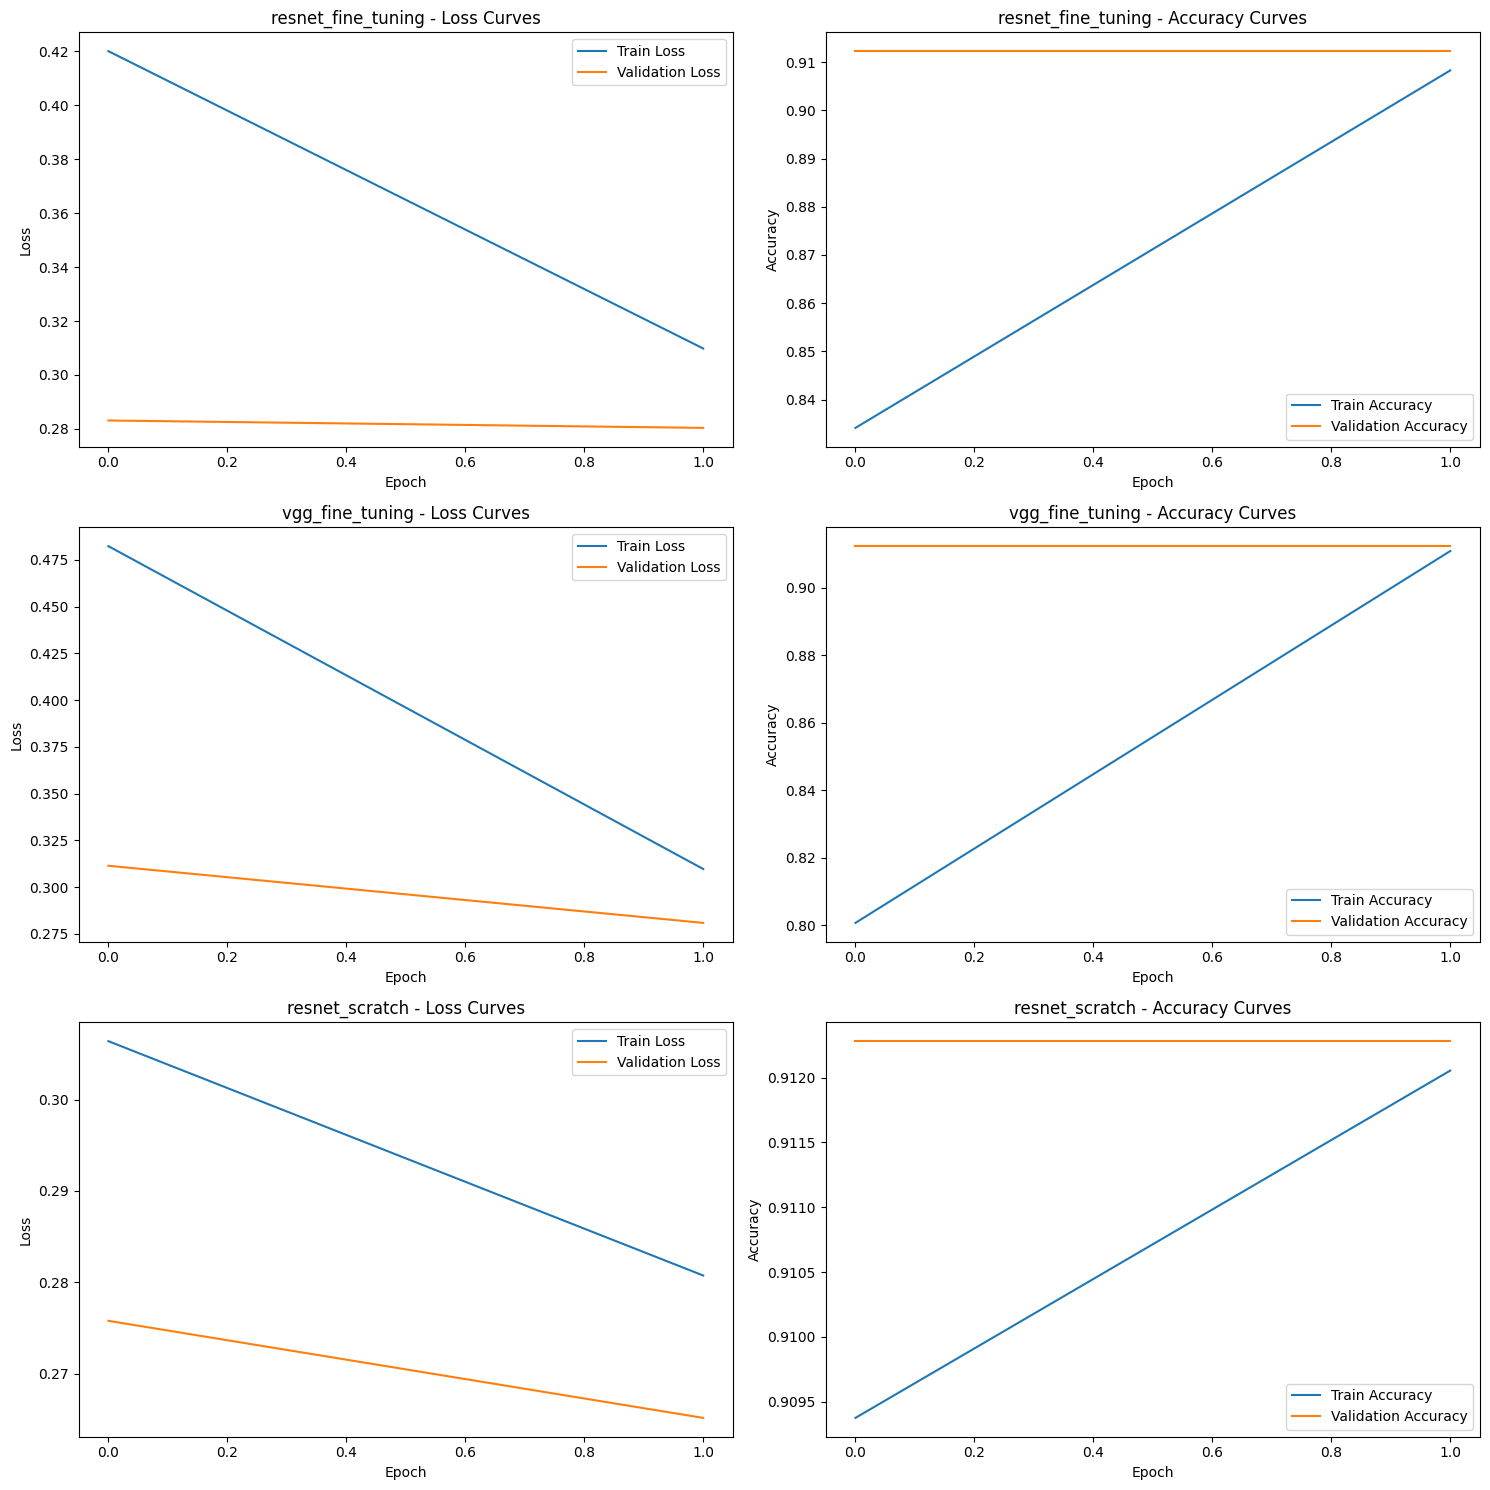


Comparaison des modèles:
                        loss  accuracy  precision  recall  f1_score  \
resnet_fine_tuning  0.281190  0.912688        0.0     0.0       0.0   
vgg_fine_tuning     0.280516  0.912688        0.0     0.0       0.0   
resnet_scratch      0.265460  0.912688        0.0     0.0       0.0   

                    average_precision   auc_roc  
resnet_fine_tuning           0.116853  0.551436  
vgg_fine_tuning              0.119478  0.576969  
resnet_scratch               0.172250  0.668363  

Meilleur modèle par accuracy: resnet_fine_tuning
Meilleur modèle par F1 score: resnet_fine_tuning
Meilleur modèle par AUC-ROC: resnet_scratch

Modèle final choisi: resnet_fine_tuning


In [32]:

# Tracer les courbes d'apprentissage pour comparer les modèles
def plot_all_learning_curves():
    fig, axes = plt.subplots(len(models), 2, figsize=(15, 5 * len(models)))
    
    for i, (name, history) in enumerate(histories.items()):
        # Tracer la perte
        axes[i, 0].plot(history.history['loss'], label='Train Loss')
        axes[i, 0].plot(history.history['val_loss'], label='Validation Loss')
        axes[i, 0].set_title(f'{name} - Loss Curves')
        axes[i, 0].set_xlabel('Epoch')
        axes[i, 0].set_ylabel('Loss')
        axes[i, 0].legend()
        
        # Tracer l'accuracy
        axes[i, 1].plot(history.history['accuracy'], label='Train Accuracy')
        axes[i, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[i, 1].set_title(f'{name} - Accuracy Curves')
        axes[i, 1].set_xlabel('Epoch')
        axes[i, 1].set_ylabel('Accuracy')
        axes[i, 1].legend()
    
    plt.tight_layout()
    plt.show()

plot_all_learning_curves()

# Créer un tableau comparatif des résultats
results_df = pd.DataFrame(results).T
print("\nComparaison des modèles:")
print(results_df)

# Trouver le meilleur modèle selon différentes métriques
best_accuracy = results_df['accuracy'].idxmax()
best_f1 = results_df['f1_score'].idxmax()
best_auc = results_df['auc_roc'].idxmax()

print(f"\nMeilleur modèle par accuracy: {best_accuracy}")
print(f"Meilleur modèle par F1 score: {best_f1}")
print(f"Meilleur modèle par AUC-ROC: {best_auc}")

# Choix du modèle final (basé sur F1 score dans cet exemple)
best_model_name = best_f1
best_model = models[best_model_name]
print(f"\nModèle final choisi: {best_model_name}")